# Bangla Sports Sentiment Analysis - Advanced Stacking Model (RF + CNN + TNN → LR)

In [ ]:
!pip install pandas numpy scikit-learn matplotlib tensorflow openpyxl

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
df = pd.read_excel('/content/Bangla_Sports_Sentiment_Analysis_Dataset.xlsx')
df['text'] = df.iloc[:,0].astype(str)
df['label'] = df.iloc[:,1].map({'Positive':1,'Negative':0})
df = df.dropna(subset=['label'])

In [ ]:
temp_df = pd.read_excel('/content/Bangla_Sports_Sentiment_Analysis_Dataset.xlsx')
print("Unique values and their counts in the second column (df.iloc[:,1]) before mapping:")
print(temp_df.iloc[:,1].value_counts(dropna=False))

Unique values and their counts in the second column (df.iloc[:,1]) before mapping:
Category
Negative    41355
Positive    41256
Name: count, dtype: int64


In [ ]:
temp_df = pd.read_excel('/content/Bangla_Sports_Sentiment_Analysis_Dataset.xlsx')
print("Unique values and their counts in the second column (df.iloc[:,1]) before mapping:")
print(temp_df.iloc[:,1].value_counts(dropna=False))

Unique values and their counts in the second column (df.iloc[:,1]) before mapping:
Category
Negative    41355
Positive    41256
Name: count, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(df['text'], df['label'], test_size=0.2, random_state=42)

In [ ]:
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [ ]:
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(X_train)
X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=100)
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=100)

In [ ]:
rf = RandomForestClassifier(n_estimators=200)
rf.fit(X_train_tfidf, y_train)
rf_pred_train = rf.predict_proba(X_train_tfidf)
rf_pred_test = rf.predict_proba(X_test_tfidf)

In [ ]:
cnn = Sequential([
Embedding(5000,128,input_length=100),
Conv1D(128,5,activation='relu'),
GlobalMaxPooling1D(),
Dense(64,activation='relu'),
Dense(1,activation='sigmoid')])
cnn.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])
cnn.fit(X_train_seq,y_train,epochs=5,batch_size=64,validation_split=0.1)
cnn_pred_train = cnn.predict(X_train_seq)
cnn_pred_test = cnn.predict(X_test_seq)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
930/930 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.7513 - loss: 0.5007 - val_accuracy: 0.7842 - val_loss: 0.4552
Epoch 2/5
930/930 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8353 - loss: 0.3711 - val_accuracy: 0.8004 - val_loss: 0.4438
Epoch 3/5
930/930 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8922 - loss: 0.2651 - val_accuracy: 0.7959 - val_loss: 0.4799
Epoch 4/5
930/930 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9216 - loss: 0.2018 - val_accuracy: 0.7995 - val_loss: 0.5294
Epoch 5/5
930/930 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9332 - loss: 0.1638 - val_accuracy: 0.8031 - val_loss: 0.5612
2066/2066 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
517/517 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
tnn = Sequential([
Embedding(5000,128,input_length=100),
GlobalMaxPooling1D(),
Dense(64,activation='relu'),
Dense(1,activation='sigmoid')])
tnn.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])
tnn.fit(X_train_seq,y_train,epochs=5,batch_size=64,validation_split=0.1)
tnn_pred_train = tnn.predict(X_train_seq)
tnn_pred_test = tnn.predict(X_test_seq)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


930/930 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7474 - loss: 0.5075 - val_accuracy: 0.7814 - val_loss: 0.4584
Epoch 2/5
930/930 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8222 - loss: 0.3943 - val_accuracy: 0.7924 - val_loss: 0.4495
Epoch 3/5
930/930 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8580 - loss: 0.3280 - val_accuracy: 0.7992 - val_loss: 0.4578
Epoch 4/5
930/930 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8877 - loss: 0.2670 - val_accuracy: 0.8007 - val_loss: 0.4728
Epoch 5/5
930/930 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9128 - loss: 0.2142 - val_accuracy: 0.8051 - val_loss: 0.5085
2066/2066 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
517/517 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
X_train_stack = np.column_stack((rf_pred_train[:,1], cnn_pred_train.flatten(), tnn_pred_train.flatten()))
X_test_stack = np.column_stack((rf_pred_test[:,1], cnn_pred_test.flatten(), tnn_pred_test.flatten()))

In [ ]:
meta = LogisticRegression()
meta.fit(X_train_stack,y_train)
pred = meta.predict(X_test_stack)
print('Accuracy:',accuracy_score(y_test,pred))
print(classification_report(y_test,pred))

Accuracy: 0.8195848211583853
              precision    recall  f1-score   support

           0       0.83      0.81      0.82      8441
           1       0.81      0.83      0.82      8082

    accuracy                           0.82     16523
   macro avg       0.82      0.82      0.82     16523
weighted avg       0.82      0.82      0.82     16523



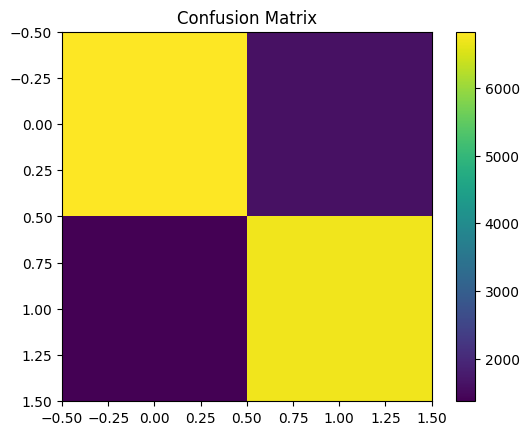

In [ ]:
cm = confusion_matrix(y_test,pred)
plt.imshow(cm)
plt.title('Confusion Matrix')
plt.colorbar()
plt.show()

### Better Confusion Matrix Visualization with Seaborn

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix (Seaborn)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

NameError: name 'cm' is not defined

<Figure size 800x600 with 0 Axes>